# 7. Supervised Deep Learning Classifier

This notebook trains a **tabular MLP fraud classifier** on the same IEEE-CIS processed feature set used by the classical models.

It uses:
- chronological split from `data/processed`
- standardized inputs
- `BCEWithLogitsLoss` with `pos_weight` for class imbalance
- early stopping on validation AUPRC

This notebook gives the project a true **supervised deep learning baseline**, complementing AE and VAE.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix, f1_score

sns.set_style('whitegrid')
torch.manual_seed(42)
np.random.seed(42)

ROOT = Path().resolve().parent
with open(ROOT / 'data/processed/dataset_info.json', 'r') as f:
    info = json.load(f)

train_ieee = pd.read_parquet(ROOT / 'data/processed/ieee_train.parquet')
test_ieee  = pd.read_parquet(ROOT / 'data/processed/ieee_test.parquet')

all_ieee = info['ieee']['raw_features'] + info['ieee']['engineered_features']
X = train_ieee[all_ieee].fillna(-999).copy()
X_test = test_ieee[all_ieee].fillna(-999).copy()
y = train_ieee['isFraud'].values
y_test = test_ieee['isFraud'].values

# Keep the final 20% of the training block as a validation set to preserve time order.
val_start = int(len(X) * 0.8)
X_train, X_val = X.iloc[:val_start], X.iloc[val_start:]
y_train, y_val = y[:val_start], y[val_start:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Train / Val / Test:', X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)


Device: cpu
Train / Val / Test: (377945, 64) (94487, 64) (118108, 64)


In [2]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.2):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden_dims)
        for i in range(len(dims) - 1):
            layers.extend([
                nn.Linear(dims[i], dims[i+1]),
                nn.BatchNorm1d(dims[i+1]),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
        layers.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def make_loader(X, y, batch_size=1024, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def predict_scores(model, X, batch_size=2048):
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)), batch_size=batch_size, shuffle=False)
    out = []
    with torch.no_grad():
        for (xb,) in loader:
            logits = model(xb.to(DEVICE))
            probs = torch.sigmoid(logits).cpu().numpy()
            out.append(probs)
    return np.concatenate(out)


In [3]:
train_loader = make_loader(X_train_scaled, y_train, batch_size=1024, shuffle=True)
val_loader = make_loader(X_val_scaled, y_val, batch_size=2048, shuffle=False)

model = MLPClassifier(input_dim=X_train_scaled.shape[1]).to(DEVICE)
pos_weight = torch.tensor([(y_train == 0).sum() / max((y_train == 1).sum(), 1)], dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_state = None
best_val_auprc = -np.inf
patience = 5
patience_counter = 0
history = []

for epoch in range(25):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    val_scores = predict_scores(model, X_val_scaled)
    val_auprc = average_precision_score(y_val, val_scores)
    epoch_loss = float(np.mean(batch_losses))
    history.append({'epoch': epoch + 1, 'train_loss': epoch_loss, 'val_auprc': val_auprc})
    print(f"Epoch {epoch+1:02d} | train_loss={epoch_loss:.5f} | val_auprc={val_auprc:.5f}")

    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print('Early stopping triggered.')
            break

model.load_state_dict(best_state)


Epoch 01 | train_loss=0.85230 | val_auprc=0.44872
Epoch 02 | train_loss=0.76831 | val_auprc=0.47858
Epoch 03 | train_loss=0.74043 | val_auprc=0.50086
Epoch 04 | train_loss=0.72442 | val_auprc=0.51177
Epoch 05 | train_loss=0.71193 | val_auprc=0.48876
Epoch 06 | train_loss=0.69820 | val_auprc=0.51801
Epoch 07 | train_loss=0.69064 | val_auprc=0.52388
Epoch 08 | train_loss=0.68396 | val_auprc=0.53143
Epoch 09 | train_loss=0.67486 | val_auprc=0.52325
Epoch 10 | train_loss=0.66900 | val_auprc=0.52926
Epoch 11 | train_loss=0.65424 | val_auprc=0.52929
Epoch 12 | train_loss=0.65258 | val_auprc=0.53521
Epoch 13 | train_loss=0.64314 | val_auprc=0.53399
Epoch 14 | train_loss=0.63674 | val_auprc=0.53438
Epoch 15 | train_loss=0.63061 | val_auprc=0.53514
Epoch 16 | train_loss=0.62569 | val_auprc=0.54125
Epoch 17 | train_loss=0.62881 | val_auprc=0.53989
Epoch 18 | train_loss=0.61509 | val_auprc=0.54316
Epoch 19 | train_loss=0.60846 | val_auprc=0.54251
Epoch 20 | train_loss=0.60477 | val_auprc=0.53983


<All keys matched successfully>

In [4]:
# TEST EVALUATION
history_df = pd.DataFrame(history)
test_scores = predict_scores(model, X_test_scaled)

auprc = average_precision_score(y_test, test_scores)
roc = roc_auc_score(y_test, test_scores)
precision, recall, thresholds = precision_recall_curve(y_test, test_scores)
f1_vals = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_vals)
best_thr = thresholds[best_idx]
y_pred = (test_scores >= best_thr).astype(int)

results = {
    'model': 'Supervised_MLP',
    'AUPRC': auprc,
    'ROC_AUC': roc,
    'best_f1_threshold': float(best_thr),
    'best_f1': float(f1_score(y_test, y_pred)),
    'precision_at_best_f1': float(precision[:-1][best_idx]),
    'recall_at_best_f1': float(recall[:-1][best_idx]),
    'confusion_matrix': confusion_matrix(y_test, y_pred).tolist()
}

pd.Series(results)


model                                   Supervised_MLP
AUPRC                                         0.449423
ROC_AUC                                        0.90358
best_f1_threshold                             0.937727
best_f1                                       0.462456
precision_at_best_f1                          0.488895
recall_at_best_f1                              0.43873
confusion_matrix        [[112180, 1864], [2281, 1783]]
dtype: object

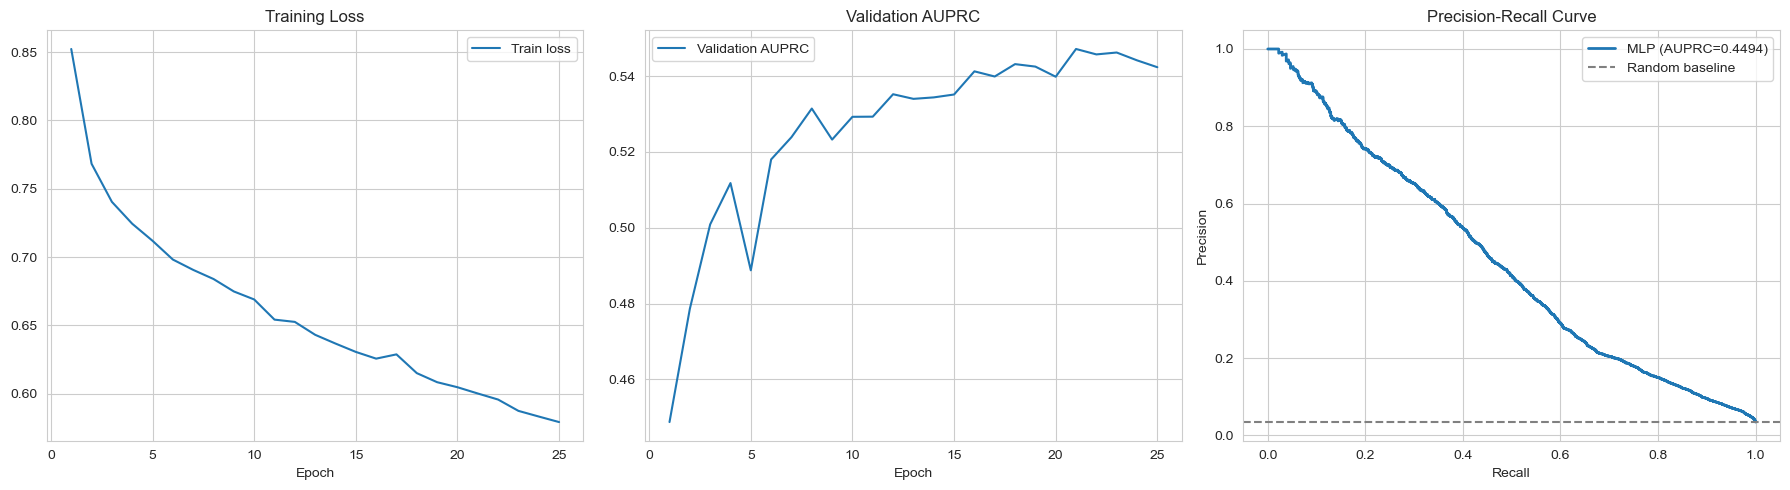

In [5]:
# VISUALS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_auprc'], label='Validation AUPRC')
axes[1].set_title('Validation AUPRC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(recall, precision, linewidth=2, label=f"MLP (AUPRC={auprc:.4f})")
axes[2].axhline(y=y_test.mean(), linestyle='--', color='gray', label='Random baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()


In [6]:
# SAVE OUTPUTS FOR NOTEBOOK 08
results_dir = ROOT / 'data/processed/dl_results'
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({'y_true': y_test, 'mlp_score': test_scores}).to_csv(results_dir / 'supervised_dl_scores_ieee.csv', index=False)
pd.DataFrame([results]).to_csv(results_dir / 'supervised_dl_summary_ieee.csv', index=False)

pd.DataFrame(history).to_csv(results_dir / 'supervised_dl_history_ieee.csv', index=False)
pd.Series(results)


model                                   Supervised_MLP
AUPRC                                         0.449423
ROC_AUC                                        0.90358
best_f1_threshold                             0.937727
best_f1                                       0.462456
precision_at_best_f1                          0.488895
recall_at_best_f1                              0.43873
confusion_matrix        [[112180, 1864], [2281, 1783]]
dtype: object